# Comando para instalar bibliotecas utilizando o conda(no terminal, ou linha de comando):

# conda install -c conda-forge 'nome da biblioteca'

read_file() -> Lê um arquivo e transforma em uma geodataframe (Passo como argumento o caminho do arquivo)

head() -> Mostra as cinco primeira linhas do geodataframe

columns -> Mostra as colunas do geodataframe

crs - > Mostra o sistema de coordenadas atual do geodataframe

plot() -> Plotar visualmente o geodataframe (Aceita argumentos)
    - color -> Escolhe a cor de preenchimento do fundo
    - figsize -> Escolhe o tamanho da figura a ser gerada
    - edgecolor -> Escolhe a cor da linha da plotagem

gdf[gdf['nomadacoluna'] operador critério] -> Aceita qualquer operador de comparação, pode ser aplicado em qualquer coluna, qualquer critério lógico pode ser utilizado

gdf_filtro2.plot(ax=nome da primeira plotagem, color='red',label='Pastagem') -> Faz uma plotagem dupla

gdf.geometry.centroid - > Calcula o centróide da geometria

gdf.centroid.x -> Calcula a longitude do centróide

gdf.centroid.y -> Calcula a latitude do ceentróide

gdf.set_crs(epsg=4326,inplace=True,allow_override=True) -> Escolhe o sistema de coordenadas de um geodataframe
    - epsg -> Código epsg do sistema de coordenadas
    - inplace -> permite alterar sem salvar um novo dataframe
    - allow_override -> Permite que o sistema existente seja reescrito

gdf.to_crs(epsg=32723) - > Faz a reprojeção do sistema de coordenadas para um sistema qualquer
    - epsg -> código epsg de destino

gdf.area -> Calcula a área de cada polígono do meu geodataframe

In [1]:
# Importa a biblioteca geopandas para ser utilizada no projeto
import geopandas as gpd

In [2]:
# Declara uma variável(gdf) e atribui a essa variável um valor(um geodataframe)
gdf = gpd.read_file(r'E:\mapbiomas_split\raster_10_14.gpkg')

C:\Users\Vitor\anaconda3\envs\vetores_geodev\Lib\site-packages\pyogrio\core.py:36: RuntimeWarning: Could not detect PROJ data files.  Set PROJ_LIB environment variable to the correct path.
  _init_proj_data()


In [12]:
# Mostar na tela (print) as cinco primeiras linhas do geodataframe
print(gdf.head())

   DN     idx                                           geometry
0   3  140090  POLYGON ((-61.23267 -10.9272, -61.23267 -10.92...
1   3  140091  POLYGON ((-61.22243 -10.9272, -61.22243 -10.92...
2   6  140092  POLYGON ((-61.22162 -10.9272, -61.22162 -10.92...
3   6  140093  POLYGON ((-61.03217 -10.9272, -61.03217 -10.92...
4  15  140094  POLYGON ((-60.93704 -10.9272, -60.93704 -10.92...


In [14]:
# Mostrando na tela as colunas do arquivo
print(gdf.columns)

Index(['DN', 'idx', 'geometry'], dtype='object')


In [15]:
# Mostrando na tela o sistema de coordenadas do arquivo
print(gdf.crs)

GEOGCS["Undefined geographic SRS",DATUM["unknown",SPHEROID["unknown",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST]]


<Axes: >

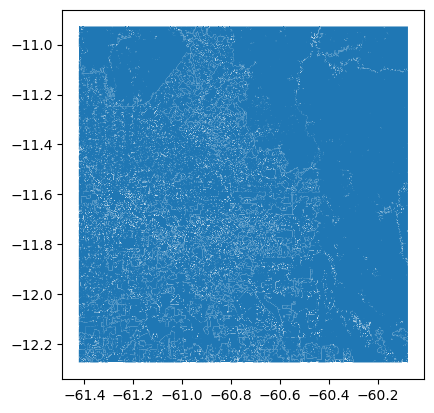

In [16]:
# Fazendo uma plotagem sem passar parâmetros
gdf.plot()

<Axes: >

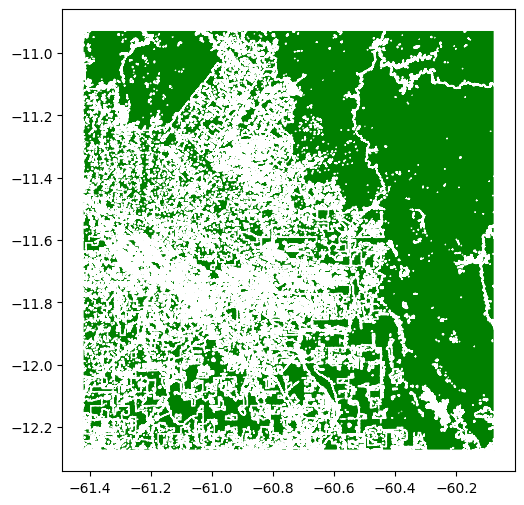

In [47]:
# Fazendo uma plotagem passando parâmetros
gdf.plot(color='green', edgecolor='white', figsize=(10,6))

In [52]:
# Filtragem do geodataframe
gdf_filtro = gdf[gdf['DN'] <= 3]

<Axes: >

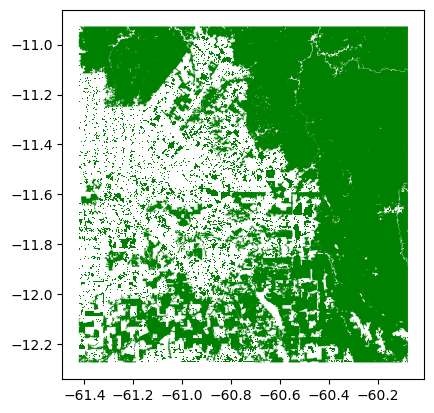

In [53]:
# Plotagem passando parâmetros
gdf_filtro.plot(color = 'green')

In [22]:
gdf_filtro2 = gdf[gdf['DN'] == 15]

<Axes: >

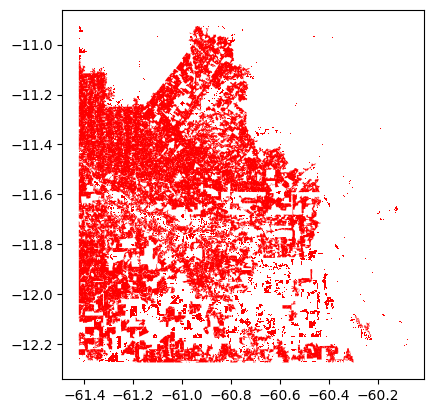

In [27]:
gdf_filtro2.plot(color = 'red')

[]

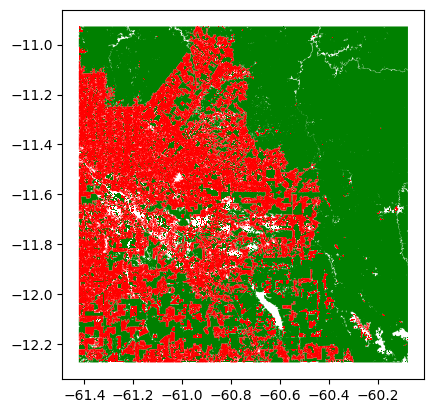

In [34]:
# Crio uma variável para armazenar a primeira plotagem
ax = gdf_filtro.plot(color='green',label='Vegetação')
# Criar a segunda plotagem e jogá-la na primeira plotagem
gdf_filtro2.plot(ax=ax, color='red',label='Pastagem')
# Mostro a plotagem com as duas imagens
ax.plot()

In [55]:
# Cálculo do centróide de cada polígono
gdf['centroid'] = gdf.geometry.centroid
# Cálculo da longitude do centróide
gdf['x'] = gdf.centroid.x
# Cálculo da latitude do centróide
gdf['y'] = gdf.centroid.y
# Mostrar na tela as colunas que eu desejo
print(gdf[['centroid','x','y']].head())

C:\Users\Vitor\AppData\Local\Temp\ipykernel_11628\3586741843.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['centroid'] = gdf.geometry.centroid


                      centroid          x          y
0   POINT (-61.2324 -10.92733) -61.232404 -10.927332
1  POINT (-61.22203 -10.92733) -61.222028 -10.927332
2  POINT (-61.22149 -10.92733) -61.221489 -10.927332
3  POINT (-61.03176 -10.92733) -61.031765 -10.927332
4  POINT (-60.93677 -10.92733) -60.936768 -10.927332


C:\Users\Vitor\AppData\Local\Temp\ipykernel_11628\3586741843.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['x'] = gdf.centroid.x
C:\Users\Vitor\AppData\Local\Temp\ipykernel_11628\3586741843.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['y'] = gdf.centroid.y


In [36]:
print(gdf.crs)

GEOGCS["Undefined geographic SRS",DATUM["unknown",SPHEROID["unknown",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST]]


In [10]:
# Escolhe o sitema de coordenadas para atribuir ao geodataframe (Diferente de fazer uma reprojeção)
gdf.set_crs(epsg=4326,inplace=True,allow_override=True)
#inoplace é p substituir o arquivo existente, pois n to criando um novo
# o override é pq essa projeção definida vai substituir a anterior

,DN,idx,geometry
0,3,140090,"POLYGON ((-61.23267 -10.9272, -61.23267 -10.92..."
1,3,140091,"POLYGON ((-61.22243 -10.9272, -61.22243 -10.92..."
2,6,140092,"POLYGON ((-61.22162 -10.9272, -61.22162 -10.92..."
3,6,140093,"POLYGON ((-61.03217 -10.9272, -61.03217 -10.92..."
4,15,140094,"POLYGON ((-60.93704 -10.9272, -60.93704 -10.92..."
...,...,...,...
36243,3,176333,"POLYGON ((-60.37784 -12.26308, -60.37784 -12.2..."
36244,3,176334,"POLYGON ((-60.33876 -12.2744, -60.33876 -12.27..."
36245,4,176335,"POLYGON ((-60.14445 -12.27413, -60.14445 -12.2..."
36246,4,176336,"POLYGON ((-60.14203 -12.2744, -60.14203 -12.27..."


In [11]:
print(gdf.crs)

EPSG:4326


In [14]:
# Reprojeção para um sistema de coordenadas qualquer
gdf_utm = gdf.to_crs(epsg=32723)

In [15]:
print(gdf_utm.crs)

EPSG:32723


In [17]:
gdf_utm['centroid'] = gdf_utm.geometry.centroid

gdf_utm['x'] = gdf_utm.centroid.x

gdf_utm['y'] = gdf_utm.centroid.y

print(gdf_utm[['x','y']].head())

              x             y
0 -1.296292e+06  8.742835e+06
1 -1.295114e+06  8.742900e+06
2 -1.295053e+06  8.742903e+06
3 -1.273532e+06  8.744083e+06
4 -1.262763e+06  8.744668e+06


In [57]:
# Cálculo da área de cada polígono
gdf_utm['area_ha'] = gdf_utm.area / 10000

print(gdf_utm[['geometry','area_ha']].head())

                                            geometry   area_ha
0  POLYGON ((-1296323.071 8742848.641, -1296321.3...  0.189895
1  POLYGON ((-1295160.855 8742912.797, -1295159.1...  0.284813
2  POLYGON ((-1295069.103 8742917.86, -1295067.39...  0.094937
3  POLYGON ((-1273578.263 8744096.405, -1273576.5...  0.284284
4  POLYGON ((-1262794.155 8744682.292, -1262792.4...  0.189349
